# 1. Preprocessing

In [165]:
# Import library yang dibutuhkan
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import scipy.stats as stats

# library preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# library modelling
from sklearn.cluster import  KMeans

# library evaluasi
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
    confusion_matrix
)
from scipy.optimize import linear_sum_assignment

In [166]:
# Import dataset
# Dataset feature (ada 561 fitur, test+train))
dataX = pd.read_table("UCI HAR Dataset\\train\\X_train.txt", header=None, delimiter="\\s+")
dataX = pd.concat([pd.read_table("UCI HAR Dataset\\test\\X_test.txt", header=None, delimiter="\\s+"), dataX], axis=0).reset_index(drop=True)
dataX = dataX.rename(columns={i: f"X{i+1}" for i in range(0, dataX.shape[1])})
isNull = dataX.isnull().sum().sum()
# Ubah dataframe menjadi array numpy untuk efisiensi sklearn
dataX = dataX.values

print(f"Dimensi data: {dataX.shape}. Terdapat {isNull} nilai null.")

# Dataset label (ada 6 kelas aktivitas). Hanya digunakan untuk evaluasi model
dataY = pd.read_table("UCI HAR Dataset\\train\\y_train.txt", header=None)
dataY = pd.concat([pd.read_table("UCI HAR Dataset\\test\\y_test.txt", header=None), dataY], axis=0).reset_index(drop=True)
dataY = dataY.rename(columns={0: "Y"})
isNull = dataY.isnull().sum().sum()
# Ubah dataframe menjadi array numpy untuk efisiensi sklearn
dataY = dataY.values.flatten()
print(f"Dimensi label: {dataY.shape}. Terdapat {isNull} nilai null.")

# Nama label untuk keenam aktivitas
labels = pd.read_table("UCI HAR Dataset\\activity_labels.txt", header=None, delimiter="\\s+")
labels = labels.rename(columns={0: "Label", 1: "Activity"})
labels["Count"] = labels["Label"].apply(lambda x: np.sum(dataY == x))

print(labels)
labels.to_csv('output/activity_labels_count.csv', index=False)

Dimensi data: (10299, 561). Terdapat 0 nilai null.
Dimensi label: (10299,). Terdapat 0 nilai null.
   Label            Activity  Count
0      1             WALKING   1722
1      2    WALKING_UPSTAIRS   1544
2      3  WALKING_DOWNSTAIRS   1406
3      4             SITTING   1777
4      5            STANDING   1906
5      6              LAYING   1944


In [167]:
# standarisasi data fitur agar memiliki mean 0 dan standar deviasi 1.
# Dataset sebenarnya sudah distandarisasi, namun kita lakukan standarisasi ulang untuk memastikan bahwa semua 
#   fitur memiliki skala yang sama.
scaler = StandardScaler()
dataX = scaler.fit_transform(dataX)
print("Dimensi data fitur setelah standarisasi:", dataX.shape)


Dimensi data fitur setelah standarisasi: (10299, 561)


In [168]:
# kompresi fitur menggunakan PCA untuk mengurangi dimensi data dan mempercepat proses komputasi.
PCA_components = 50  # jumlah komponen PCA yang ingin dipertahankan
random_state = 42  # untuk memastikan hasil yang konsisten karena clustering sensitif terhadap inisialisasi random

pca = PCA(n_components=PCA_components, random_state=random_state)
dataX_pca = pca.fit_transform(dataX)

# Evaluasi variansi yang dijelaskan oleh komponen PCA yang dipilih
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
n_components_needed = np.argmax(cumulative_variance >= 0.85) + 1

print(f"Variansi kumulatif yang dijelaskan oleh {PCA_components} komponen PCA : {cumulative_variance[-1]:.4f}")  # ~0.85
print(f"\nVariansi individual per komponen (5 teratas):\n{pca.explained_variance_ratio_[:5]}")


print("\nDimensi data setelah PCA:", dataX_pca.shape)

Variansi kumulatif yang dijelaskan oleh 50 komponen PCA : 0.8710

Variansi individual per komponen (5 teratas):
[0.50738221 0.06239186 0.02692564 0.02452871 0.01888936]

Dimensi data setelah PCA: (10299, 50)


# 2. Pemilihan nilai $k$

In [169]:
# Tahap pemilihan nilai k model clustering

# mengambil sampel acak dari data yang sudah dikompresi dengan PCA untuk mempercepat proses clustering.
np.random.seed(random_state)
sample_indexes = np.random.choice(dataX_pca.shape[0], size=2000, replace=False)
dataX_sample = dataX_pca[sample_indexes]

print("Dimensi data sample:", dataX_sample.shape, "\n")

# test clustering dengan K-Means
# nilai k berbeda untuk melihat performa model di jumlah cluster yang berbeda.
k_range = range(2, 11)

# parameter evaluasi model
inertia_values = []
sillhouette_values = []

# proses clustering
for k in k_range:
    kmeans_temp = KMeans(n_clusters=k,              # Jumlah cluster yang ingin dibentuk
                        init="k-means++",           # Inisialisasi centroid menggunakan metode k-means++
                        n_init=5,                   # Jumlah inisialisasi ulang, diambil terbaik
                        random_state=random_state,  # Memastikan hasil konsisten karena clustering sensitif terhadap inisialisasi random
    )

    # fitting model dan prediksi label cluster untuk data sample
    labels_temp = kmeans_temp.fit_predict(dataX_sample)

    # evaluasi model dengan inertia dan silhouette score
    # inertia: jumlah kuadrat jarak antara sampel dan centroid terdekatnya, semakin kecil semakin baik.
    inertia_values.append(kmeans_temp.inertia_) 
    
    # silhouette score: mengukur seberapa mirip objek dengan cluster-nya sendiri dibandingkan dengan cluster lain, 
    #                   nilai antara -1 dan 1, semakin tinggi semakin baik.
    sil = silhouette_score(dataX_sample, labels_temp, sample_size=500, random_state=random_state)
    sillhouette_values.append(sil)

    print(f"K={k}: Inertia={kmeans_temp.inertia_:.2f}, Silhouette Score={sil:.4f}")  # Tampilkan hanya jika ini adalah inertia terkecil sejauh ini

Dimensi data sample: (2000, 50) 

K=2: Inertia=495116.33, Silhouette Score=0.4386
K=3: Inertia=427647.42, Silhouette Score=0.3437
K=4: Inertia=399085.70, Silhouette Score=0.2183
K=5: Inertia=372974.69, Silhouette Score=0.1981
K=6: Inertia=357535.04, Silhouette Score=0.1493
K=7: Inertia=344542.24, Silhouette Score=0.1150
K=8: Inertia=334428.62, Silhouette Score=0.1134
K=9: Inertia=326462.46, Silhouette Score=0.1065
K=10: Inertia=315651.56, Silhouette Score=0.1087


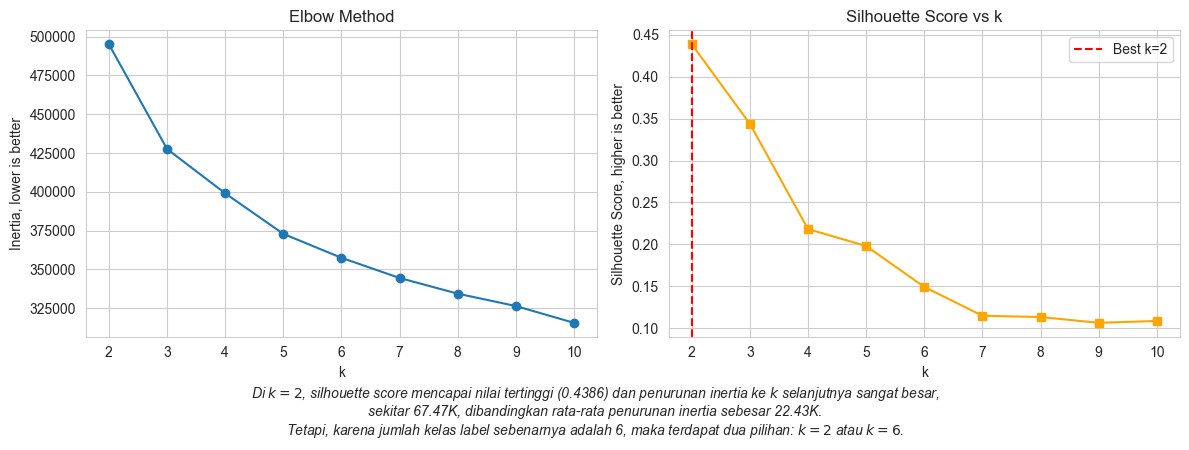

In [170]:
# Visualisasi evaluasi inertia dan silhouette score untuk berbagai nilai k
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
 
axes[0].plot(k_range, inertia_values, marker='o')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia, lower is better')
axes[0].set_title('Elbow Method')
 
axes[1].plot(k_range, sillhouette_values, marker='s', color='orange')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette Score, higher is better')
axes[1].set_title('Silhouette Score vs k')
axes[1].axvline(x=k_range[np.argmax(sillhouette_values)], color='red', linestyle='--', 
                label=f'Best k={k_range[np.argmax(sillhouette_values)]}')
axes[1].legend()
 
message = (
    f"Di $k = 2$, silhouette score mencapai nilai tertinggi "
    f"({sillhouette_values[0]:.4f}) dan penurunan inertia ke "
    f"$k$ selanjutnya sangat besar,\nsekitar "
    f"{(inertia_values[0] - inertia_values[1])/1000:,.2f}K, "
    f"dibandingkan rata-rata penurunan inertia sebesar "
    f"{abs(np.mean(np.diff(inertia_values)))/1000:,.2f}K.\n"
    f"Tetapi, karena jumlah kelas label sebenarnya adalah 6, "
    f"maka terdapat dua pilihan: $k = 2$ atau $k = 6$."
)
fig.text(0.5, -0.1, message, ha='center', fontsize=10, style='italic')
# save output
plt.savefig('output/k_value_analysis.png', dpi=300)
plt.tight_layout()

plt.show()


Berdasarkan analisis elbow dan silhouette, terdapat dua pilihan jumlah kluster yang dapat dibuat oleh model: $k=2$ atau $k=6$. 

# 3. Pembuatan Model

## a. Model dengan $k=6$

In [171]:
# Pembuatan model clustering dengan K-Means menggunakan k=6
k_optimal = 6
kmeans = KMeans(n_clusters=k_optimal,       # Jumlah cluster yang ingin dibentuk
                init="k-means++",           # Inisialisasi centroid menggunakan metode k-means++
                n_init=10,                  # Jumlah inisialisasi ulang, diambil terbaik    
                random_state=random_state,  # memastikan hasil konsisten karena clustering sensitif terhadap inisialisasi random
)

# fit model dan prediksi label cluster untuk seluruh data yang sudah dikompresi dengan PCA
cluster_labels = kmeans.fit_predict(dataX_pca)
cluster_labels = cluster_labels + 1     # penyesuaian label cluster agar mulai dari 1 (sesuai dengan label kelas sebenarnya)

centroids = kmeans.cluster_centers_
inertia_values = kmeans.inertia_

print(f"Konvergensi K-Means: {kmeans.n_iter_ < 300}")
print(f"Nilai Inertia: {inertia_values:.2f}")
print(f"Distribusi Cluster:\n{pd.Series(cluster_labels).value_counts().sort_index()}")

Konvergensi K-Means: True
Nilai Inertia: 1833594.42
Distribusi Cluster:
1    2630
2     308
3    2449
4    1919
5    1343
6    1650
Name: count, dtype: int64


Silhouette Score: 0.1545
Davies-Bouldin Score: 1.9683
Calinski-Harabasz Score: 3591.2862
Adjusted Rand Index (ARI): 0.4201
Normalized Mutual Information (NMI): 0.5597


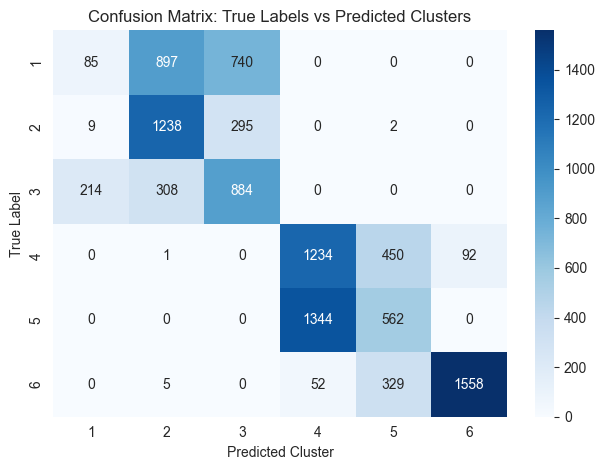

Accuracy (dari confusion matrix): 0.5400


In [172]:
# Evaluasi model clustering dengan metrik internal dan eksternal

# Metrik internal: silhouette score, davies-bouldin score, calinski-harabasz score
# 1. Silhouette Score: mengukur seberapa mirip objek dengan cluster-nya sendiri dibandingkan dengan cluster lain,
#    Range [-1, 1), semakin tinggi semakin baik.
silhouette_avg = silhouette_score(dataX_pca, cluster_labels, sample_size=3000, random_state=random_state)
print(f"Silhouette Score: {silhouette_avg:.4f}")

# 2. Davies-Bouldin Score: mengukur seberapa baik cluster terpisah satu sama lain, 
#    Range [0, inf), semakin kecil semakin baik.
davies_bouldin = davies_bouldin_score(dataX_pca, cluster_labels)
print(f"Davies-Bouldin Score: {davies_bouldin:.4f}")

# 3. Calinski-Harabasz Score: mengukur seberapa baik cluster terpisah satu sama lain, 
#    Range [0, inf), semakin besar semakin baik.
calinski_harabasz = calinski_harabasz_score(dataX_pca, cluster_labels)
print(f"Calinski-Harabasz Score: {calinski_harabasz:.4f}")



# Metrik eksternal: adjusted rand index (ARI), normalized mutual information (NMI), Confusion Matrix
# Metrik ini menggunakan label asli (dataY) untuk mengevaluasi seberapa baik hasil clustering sesuai dengan kelas sebenarnya.
# 1. Adjusted Rand Index (ARI): mengukur kesamaan antara dua pengelompokan, dengan penyesuaian untuk pengelompokan acak, 
#    Range [-1, 1), semakin tinggi semakin baik. 1 = match sempurna.
ari = adjusted_rand_score(dataY, cluster_labels)
print(f"Adjusted Rand Index (ARI): {ari:.4f}")

# 2. Normalized Mutual Information (NMI): mengukur kesamaan antara dua pengelompokan, dengan normalisasi untuk skala,
#    Range [0, 1), semakin tinggi semakin baik. 1 = pengelompokan sempurna, 0 = tidak ada kesamaan.
nmi = normalized_mutual_info_score(dataY, cluster_labels)
print(f"Normalized Mutual Information (NMI): {nmi:.4f}")

# 3. Confusion Matrix: matriks yang menunjukkan jumlah sampel yang benar-benar diklasifikasikan ke dalam setiap cluster
#    baris = label asli (dataY), kolom = label cluster yang diprediksi (cluster_labels)
conf_matrix = confusion_matrix(dataY, cluster_labels)
# Hungarian Algorithm untuk mencari penyesuaian terbaik antara label cluster dan label asli
#    karena model clustering bisa saja tidak mengurutkan label sesuai dengan label asli.
row_ind, col_ind = linear_sum_assignment(-conf_matrix)  # Negatif karena kita ingin memaksimalkan jumlah yang benar
conf_matrix_aligned = conf_matrix[:, col_ind]  # Sesuaikan kolom sesuai


# Visualisasi confusion matrix dengan heatmap
sns.heatmap(conf_matrix_aligned, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f'{i+1}' for i in range(k_optimal)],
            yticklabels=[f'{i+1}' for i in range(k_optimal)])
plt.title('Confusion Matrix: True Labels vs Predicted Clusters')
plt.xlabel('Predicted Cluster')
plt.ylabel('True Label')
# save output
plt.savefig('output/conf_matrix_k6.png', dpi=300)
plt.tight_layout()
plt.show()
accuracy = np.trace(conf_matrix_aligned) / np.sum(conf_matrix_aligned)
print(f"Accuracy (dari confusion matrix): {accuracy:.4f}")

# Simpan evaluasi model untuk perbandingan
evaluation_results_k6 = {
    'Inertia': inertia_values,
    'Silhouette Score': silhouette_avg,
    'Davies-Bouldin Score': davies_bouldin,
    'Calinski-Harabasz Score': calinski_harabasz,
    'Adjusted Rand Index': ari,
    'Normalized Mutual Information': nmi,
    'Confusion Matrix Accuracy': accuracy
}


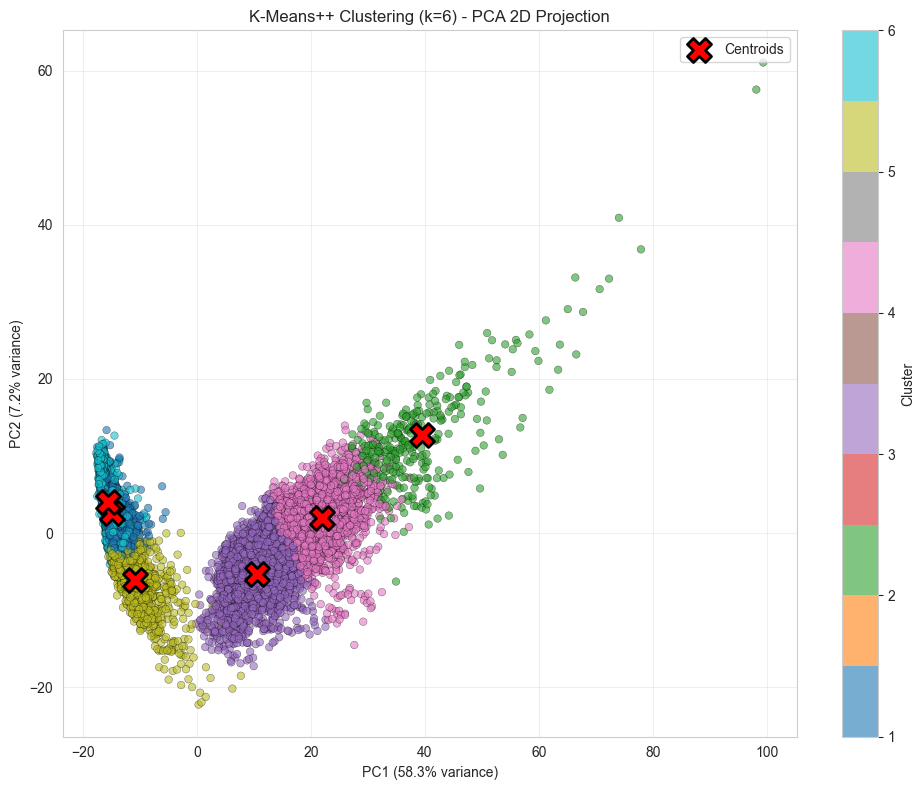

In [173]:
# PCA 2D untuk visualisasi (project ke 2 komponen utama)
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(dataX_pca)
 
# Buat scatter plot
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], 
                      c=cluster_labels,          # Warna berdasarkan cluster
                      cmap='tab10',              # Colormap dengan 10 warna
                      alpha=0.6,
                      s=30,
                      edgecolors='black',
                      linewidth=0.3)
 
# Plot centroid (harus project centroid dari 50D ke 2D)
centroids_2d = pca_2d.transform(kmeans.cluster_centers_)
plt.scatter(centroids_2d[:, 0], centroids_2d[:, 1], 
            c='red', marker='X', s=300, 
            edgecolors='black', linewidth=2,
            label='Centroids')
 
plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} variance)')
plt.title('K-Means++ Clustering (k=6) - PCA 2D Projection')
plt.colorbar(scatter, label='Cluster')
plt.legend()
plt.grid(alpha=0.3)
# save output
plt.savefig('output/kmeans_clustering_pca_2d_k6.png', dpi=300)
plt.tight_layout()
plt.show()


## b. Model dengan $k=2$

Pada model dengank = 2, label kluster dibagi menjadi dua kelompok besar:
- Cluster 1: aktivitas 1, 2, 3 (Walking, Walking Upstairs, Walking Downstairs)
- Cluster 2: aktivitas 4, 5, 6 (Sitting, Standing, Laying)

Pembagian didasarkan pada kemiripan data di masing-masing pasangan kelas (sepert SITTING vs STANDING yang memiliki nilai akselerometer mirip, ~0.9g karena pengguna IMU stasioner)

In [174]:
# Merge label menjadi dua kelas: aktivitas statis (1, 2, 3) dan aktivitas dinamis (4, 5, 6)
dataY_binary = np.where(dataY <= 3, 0, 1)  # 0 untuk aktivitas statis, 1 untuk aktivitas dinamis    

labels_binary = {0: 'Statis', 1: 'Dinamis'}
labels_binary = pd.DataFrame(list(labels_binary.items()), columns=['Label', 'Activity'])
labels_binary["Count"] = labels_binary["Label"].apply(lambda x: np.sum(dataY_binary == x))

# Validasi jumlah label binary
assert labels_binary["Count"].sum() == len(dataY_binary), "Jumlah total label binary tidak sesuai dengan jumlah dataY"
assert labels_binary["Count"].sum() == labels["Count"].sum(), "Jumlah total label binary tidak sesuai dengan jumlah label asli"

labels_binary

,Label,Activity,Count
0,0,Statis,4672
1,1,Dinamis,5627


In [175]:
# Pembuatan model clustering dengan K-Means menggunakan k=2
k_optimal = 2
kmeans = KMeans(n_clusters=k_optimal,       # Jumlah cluster yang ingin dibentuk
                init="k-means++",           # Inisialisasi centroid menggunakan metode k-means++
                n_init=10,                  # Jumlah inisialisasi ulang, diambil terbaik    
                random_state=random_state,  # memastikan hasil konsisten karena clustering sensitif terhadap inisialisasi random
)

# fit model dan prediksi label cluster untuk seluruh data yang sudah dikompresi dengan PCA
cluster_labels = kmeans.fit_predict(dataX_pca)
cluster_labels = cluster_labels     # penyesuaian label cluster agar mulai dari 1 (sesuai dengan label kelas sebenarnya)

centroids = kmeans.cluster_centers_
inertia_values = kmeans.inertia_

print(f"Konvergensi K-Means: {kmeans.n_iter_ < 300}")
print(f"Nilai Inertia: {inertia_values:.2f}")
print(f"Distribusi Cluster:\n{pd.Series(cluster_labels).value_counts().sort_index()}")

Konvergensi K-Means: True
Nilai Inertia: 2527535.19
Distribusi Cluster:
0    5620
1    4679
Name: count, dtype: int64


Silhouette Score: 0.4463
Davies-Bouldin Score: 0.9265
Calinski-Harabasz Score: 10204.4470
Adjusted Rand Index (ARI): 0.9911
Normalized Mutual Information (NMI): 0.9771


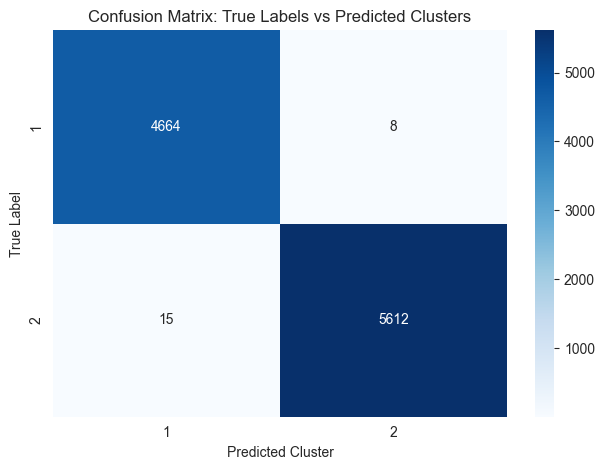

Accuracy (dari confusion matrix): 0.9978


In [176]:
# Evaluasi model clustering dengan metrik internal dan eksternal

# Metrik internal: silhouette score, davies-bouldin score, calinski-harabasz score
# 1. Silhouette Score: mengukur seberapa mirip objek dengan cluster-nya sendiri dibandingkan dengan cluster lain,
#    Range [-1, 1), semakin tinggi semakin baik.
silhouette_avg = silhouette_score(dataX_pca, cluster_labels, sample_size=3000, random_state=random_state)
print(f"Silhouette Score: {silhouette_avg:.4f}")

# 2. Davies-Bouldin Score: mengukur seberapa baik cluster terpisah satu sama lain, 
#    Range [0, inf), semakin kecil semakin baik.
davies_bouldin = davies_bouldin_score(dataX_pca, cluster_labels)
print(f"Davies-Bouldin Score: {davies_bouldin:.4f}")

# 3. Calinski-Harabasz Score: mengukur seberapa baik cluster terpisah satu sama lain, 
#    Range [0, inf), semakin besar semakin baik.
calinski_harabasz = calinski_harabasz_score(dataX_pca, cluster_labels)
print(f"Calinski-Harabasz Score: {calinski_harabasz:.4f}")



# Metrik eksternal: adjusted rand index (ARI), normalized mutual information (NMI), Confusion Matrix
# Metrik ini menggunakan label asli (dataY) untuk mengevaluasi seberapa baik hasil clustering sesuai dengan kelas sebenarnya.
# 1. Adjusted Rand Index (ARI): mengukur kesamaan antara dua pengelompokan, dengan penyesuaian untuk pengelompokan acak, 
#    Range [-1, 1), semakin tinggi semakin baik. 1 = match sempurna.
ari = adjusted_rand_score(dataY_binary, cluster_labels)
print(f"Adjusted Rand Index (ARI): {ari:.4f}")

# 2. Normalized Mutual Information (NMI): mengukur kesamaan antara dua pengelompokan, dengan normalisasi untuk skala,
#    Range [0, 1), semakin tinggi semakin baik. 1 = pengelompokan sempurna, 0 = tidak ada kesamaan.
nmi = normalized_mutual_info_score(dataY_binary, cluster_labels)
print(f"Normalized Mutual Information (NMI): {nmi:.4f}")

# 3. Confusion Matrix: matriks yang menunjukkan jumlah sampel yang benar-benar diklasifikasikan ke dalam setiap cluster
#    baris = label asli (dataY), kolom = label cluster yang diprediksi (cluster_labels)
conf_matrix = confusion_matrix(dataY_binary, cluster_labels)
# Hungarian Algorithm untuk mencari penyesuaian terbaik antara label cluster dan label asli
#    karena model clustering bisa saja tidak mengurutkan label sesuai dengan label asli.
row_ind, col_ind = linear_sum_assignment(-conf_matrix)  # Negatif karena kita ingin memaksimalkan jumlah yang benar
conf_matrix_aligned = conf_matrix[:, col_ind]  # Sesuaikan kolom sesuai


# Visualisasi confusion matrix dengan heatmap
sns.heatmap(conf_matrix_aligned, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f'{i+1}' for i in range(k_optimal)],
            yticklabels=[f'{i+1}' for i in range(k_optimal)])
plt.title('Confusion Matrix: True Labels vs Predicted Clusters')
plt.xlabel('Predicted Cluster')
plt.ylabel('True Label')
# save output
plt.savefig('output/conf_matrix_k2.png', dpi=300)
plt.tight_layout()
plt.show()
accuracy = np.trace(conf_matrix_aligned) / np.sum(conf_matrix_aligned)
print(f"Accuracy (dari confusion matrix): {accuracy:.4f}")

# Simpan evaluasi model untuk perbandingan
evaluation_results_k2 = {
    'Inertia': inertia_values,
    'Silhouette Score': silhouette_avg,
    'Davies-Bouldin Score': davies_bouldin,
    'Calinski-Harabasz Score': calinski_harabasz,
    'Adjusted Rand Index': ari,
    'Normalized Mutual Information': nmi,
    'Confusion Matrix Accuracy': accuracy
}


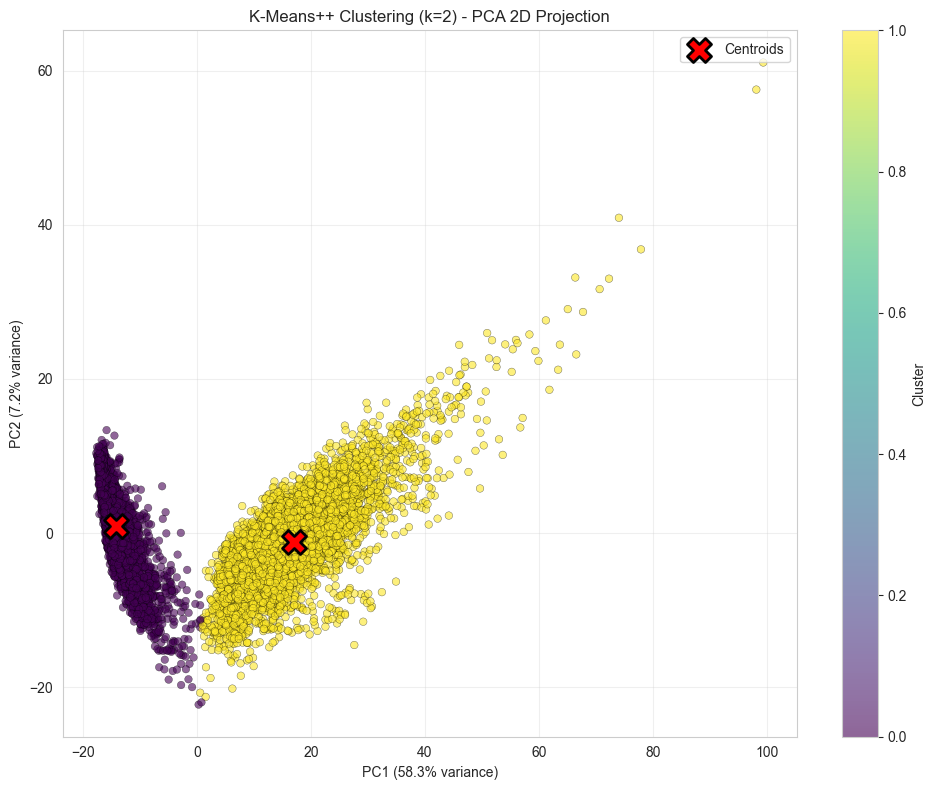

In [177]:
# PCA 2D untuk visualisasi (project ke 2 komponen utama)
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(dataX_pca)
 
# Buat scatter plot
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], 
                      c=cluster_labels,          # Warna berdasarkan cluster
                      cmap='viridis',              # Colormap dengan 10 warna
                      alpha=0.6,
                      s=30,
                      edgecolors='black',
                      linewidth=0.3)
 
# Plot centroid (harus project centroid dari 50D ke 2D)
centroids_2d = pca_2d.transform(kmeans.cluster_centers_)
plt.scatter(centroids_2d[:, 0], centroids_2d[:, 1], 
            c='red', marker='X', s=300, 
            edgecolors='black', linewidth=2,
            label='Centroids')
 
plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} variance)')
plt.title('K-Means++ Clustering (k=2) - PCA 2D Projection')
plt.colorbar(scatter, label='Cluster')
plt.legend()
plt.grid(alpha=0.3)
# save output
plt.savefig('output/kmeans_clustering_pca_2d_k2.png', dpi=300)
plt.tight_layout()
plt.show()


# 4. Perbandingan model di k berbeda

In [178]:
data_evaluation = pd.DataFrame({
    'Metric': list(evaluation_results_k6.keys()),
    'K=6': [f"{value:.3f}" for value in evaluation_results_k6.values()],
    'K=2': [f"{value:.3f}" for value in evaluation_results_k2.values()]
})

data_evaluation

# save output
data_evaluation.to_csv('output/evaluation_comparison_k2_k6.csv', index=False)